# Robo-Greeno (3+3) Hexapod — 2-minute RL quickdemo

Self-contained classroom demo. Trains a walking policy on Colab GPU in **under 2 minutes** so you can run the whole pipeline live in class.

**Before you run:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`. Target wallclock: **≤120 s**.

> **Why GPU, not TPU?** MuJoCo physics runs on CPU; the SB3 PyTorch policy benefits from GPU acceleration. TPU does not help this stack — for real TPU acceleration you'd need to rewrite the physics layer with **MJX + Brax** (JAX physics directly on accelerator, 1000+ envs in parallel). That's the "next-notebook" path; this one stays on GPU.

What you'll see (in order):
1. Model loaded in MuJoCo + rest-pose render.
2. A short clip of random-action behaviour (baseline).
3. **30 k** PPO training steps (vs 1.5M in the full version) — enough to show the training mechanics and a slight learning curve.
4. A short rollout of the partially-trained policy + top-down trajectory.

The spider will NOT walk cleanly at 30 k steps. To get a clean walking policy, use the full notebook (`robo_greeno_rl_gpu_colab.ipynb`, ~30 min training).

In [1]:
# 1. Setup + GPU check.
import os, sys, subprocess, time
T_START = time.time()

if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "mujoco", "mediapy", "gymnasium",
                           "stable-baselines3[extra]"])
    # Colab is headless Linux with GPU — EGL is the right offscreen backend.
    os.environ.setdefault("MUJOCO_GL", "egl")
# On local Windows / macOS, let MuJoCo pick its default (wgl/cgl/glfw).
# Local users running this notebook: pip install tqdm rich (for progress bar).

import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import gymnasium as gym
from gymnasium import spaces
import torch

# ffmpeg fallback for local runs (Colab has it preinstalled).
try:
    import imageio_ffmpeg
    media._config.ffmpeg_name_or_path = imageio_ffmpeg.get_ffmpeg_exe()
except ImportError:
    pass

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"MuJoCo:   {mujoco.__version__}")
print(f"PyTorch:  {torch.__version__}  device={DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:      {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU — will run on CPU, expect ~3-4x slower.")
print(f"[setup done in {time.time()-T_START:.1f}s]")

MuJoCo:   3.8.0
PyTorch:  2.12.0+cpu  device=cpu
[setup done in 1.9s]


## 1. Build the hexapod model

Six legs (3 left + 3 right) on a box chassis. 18 joint actuators. Same kinematic structure as the full notebook — only the training scope differs.

In [2]:
# 2. Model XML — identical to the full notebook.
T0 = time.time()

CHASSIS_LX, CHASSIS_LY, CHASSIS_LZ = 0.16, 0.10, 0.025
COXA_LEN, FEMUR_LEN, TIBIA_LEN = 0.05, 0.15, 0.20
BODY_Z = 0.22
REST_COXA_DEG = 0.0
REST_FEMUR_DEG = -20.0
REST_TIBIA_DEG = -60.0
ACTION_RANGE_RAD = 0.3

LEG_LAYOUT = [
    ("LF",  0.12, "L"), ("LM",  0.00, "L"), ("LR", -0.12, "L"),
    ("RF",  0.12, "R"), ("RM",  0.00, "R"), ("RR", -0.12, "R"),
]
LEG_NAMES = [n for n, _, _ in LEG_LAYOUT]

def _make_leg(name, attach_x, side):
    if side == "L":
        attach_y, fy = +CHASSIS_LY, +1
        coxa_axis, lift_axis = "0 0 -1", "1 0 0"
    else:
        attach_y, fy = -CHASSIS_LY, -1
        coxa_axis, lift_axis = "0 0 1", "-1 0 0"
    return f"""
      <body name=\"{name}_coxa\" pos=\"{attach_x} {attach_y} 0\">
        <joint name=\"{name}_coxa_j\"  axis=\"{coxa_axis}\" range=\"-45 45\"/>
        <geom  type=\"capsule\" size=\"0.012\" fromto=\"0 0 0  0 {fy*COXA_LEN} 0\" rgba=\"0.30 0.50 0.30 1\"/>
        <body name=\"{name}_femur\" pos=\"0 {fy*COXA_LEN} 0\">
          <joint name=\"{name}_femur_j\" axis=\"{lift_axis}\" range=\"-60 60\"/>
          <geom  type=\"capsule\" size=\"0.011\" fromto=\"0 0 0  0 {fy*FEMUR_LEN} 0\" rgba=\"0.20 0.65 0.40 1\"/>
          <body name=\"{name}_tibia\" pos=\"0 {fy*FEMUR_LEN} 0\">
            <joint name=\"{name}_tibia_j\" axis=\"{lift_axis}\" range=\"-90 30\"/>
            <geom  type=\"capsule\" size=\"0.009\" fromto=\"0 0 0  0 {fy*TIBIA_LEN} 0\" rgba=\"0.10 0.75 0.45 1\"/>
            <site name=\"{name}_foot\" pos=\"0 {fy*TIBIA_LEN} 0\" size=\"0.012\" rgba=\"1 0.4 0 1\"/>
          </body>
        </body>
      </body>"""

_legs_xml = "\n".join(_make_leg(n, x, s) for n, x, s in LEG_LAYOUT)
_acts = []
for n, _, _ in LEG_LAYOUT:
    for jn in (f"{n}_coxa_j", f"{n}_femur_j", f"{n}_tibia_j"):
        _acts.append(f'    <position name="{jn}_act" joint="{jn}" kp="35" forcerange="-3 3"/>')
_actuator_xml = "\n".join(_acts)

MODEL_XML = f"""
<mujoco model=\"robo_greeno_3plus3_quickdemo\">
  <compiler angle=\"degree\" autolimits=\"true\"/>
  <option gravity=\"0 0 -9.81\" timestep=\"0.005\"/>
  <visual><global offwidth=\"640\" offheight=\"360\"/></visual>
  <default>
    <joint type=\"hinge\" damping=\"0.5\" armature=\"0.005\"/>
    <geom contype=\"1\" conaffinity=\"1\" density=\"500\" friction=\"1.2 0.005 0.0001\"
          solref=\"0.005 1\" solimp=\"0.9 0.95 0.001\"/>
    <site size=\"0.012\"/>
  </default>
  <worldbody>
    <light pos=\"0 -2 2\" dir=\"0 0.5 -1\"/>
    <camera name=\"chase\" pos=\"-0.6 -0.9 0.55\" xyaxes=\"0.83 -0.55 0  0.18 0.27 0.95\" fovy=\"55\"/>
    <geom name=\"ground\" type=\"plane\" size=\"10 10 0.05\" rgba=\"0.88 0.88 0.92 1\"/>
    <body name=\"chassis\" pos=\"0 0 {BODY_Z}\">
      <freejoint name=\"root\"/>
      <geom name=\"chassis_g\" type=\"box\" size=\"{CHASSIS_LX} {CHASSIS_LY} {CHASSIS_LZ}\" rgba=\"0.20 0.50 0.30 1\"/>
      {_legs_xml}
    </body>
  </worldbody>
  <actuator>
{_actuator_xml}
  </actuator>
</mujoco>
"""

_test_model = mujoco.MjModel.from_xml_string(MODEL_XML)
print(f"loaded: nq={_test_model.nq}, nu={_test_model.nu}, nbody={_test_model.nbody}")
print(f"[model build {time.time()-T0:.1f}s]")

loaded: nq=25, nu=18, nbody=20
[model build 0.0s]


""

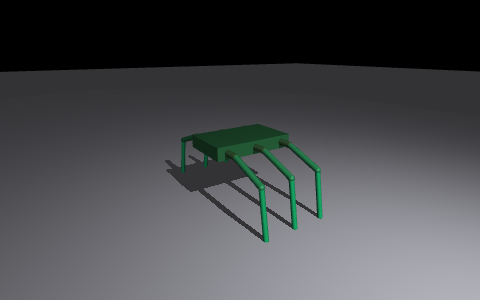

[rest render 0.3s]


In [3]:
# 3. Render rest pose.
T0 = time.time()
_d = mujoco.MjData(_test_model)
_d.qpos[0:7] = [0, 0, BODY_Z, 1, 0, 0, 0]
for i, n in enumerate(LEG_NAMES):
    _d.qpos[7 + 3*i + 0] = np.deg2rad(REST_COXA_DEG)
    _d.qpos[7 + 3*i + 1] = np.deg2rad(REST_FEMUR_DEG)
    _d.qpos[7 + 3*i + 2] = np.deg2rad(REST_TIBIA_DEG)
mujoco.mj_forward(_test_model, _d)

with mujoco.Renderer(_test_model, height=300, width=480) as r:
    r.update_scene(_d, "chase")
    media.show_image(r.render())
print(f"[rest render {time.time()-T0:.1f}s]")

## 2. The Gymnasium environment

Identical to the full notebook — 18-dim continuous action, 53-dim observation, forward-velocity reward with alive/upright/control penalties.

In [4]:
# 4. HexapodEnv — same as the full notebook.
class HexapodEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"], "render_fps": 40}

    def __init__(self, xml_string=MODEL_XML, frame_skip=5, max_steps=500, render_mode=None):
        super().__init__()
        self.xml = xml_string
        self.model = mujoco.MjModel.from_xml_string(self.xml)
        self.data = mujoco.MjData(self.model)
        self.frame_skip = frame_skip
        self.max_steps = max_steps
        self.render_mode = render_mode

        self._leg_names = LEG_NAMES
        self._joint_qpos = {}
        for n in self._leg_names:
            for j in ("coxa", "femur", "tibia"):
                jid = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_JOINT, f"{n}_{j}_j")
                self._joint_qpos[(n, j)] = self.model.jnt_qposadr[jid]
        self._foot_site_ids = {
            n: mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_SITE, f"{n}_foot")
            for n in self._leg_names
        }
        self.chassis_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_BODY, "chassis")
        self._rest_ctrl = np.array([np.deg2rad(REST_COXA_DEG),
                                    np.deg2rad(REST_FEMUR_DEG),
                                    np.deg2rad(REST_TIBIA_DEG)] * 6, dtype=np.float32)

        self.action_space = spaces.Box(-1.0, 1.0, (self.model.nu,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, (53,), dtype=np.float32)
        self._step_count = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[0:7] = [0.0, 0.0, BODY_Z, 1.0, 0.0, 0.0, 0.0]
        for n in self._leg_names:
            self.data.qpos[self._joint_qpos[(n, "coxa")]] = np.deg2rad(REST_COXA_DEG)
            self.data.qpos[self._joint_qpos[(n, "femur")]] = np.deg2rad(REST_FEMUR_DEG)
            self.data.qpos[self._joint_qpos[(n, "tibia")]] = np.deg2rad(REST_TIBIA_DEG)
        self.data.qpos[7:] += self.np_random.uniform(-0.03, 0.03, size=self.model.nq - 7)
        mujoco.mj_forward(self.model, self.data)
        self._step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        action = np.clip(action, -1.0, 1.0).astype(np.float32)
        self.data.ctrl[:] = self._rest_ctrl + ACTION_RANGE_RAD * action
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        obs = self._get_obs()
        reward = self._get_reward()
        terminated = self._fell_over()
        self._step_count += 1
        truncated = self._step_count >= self.max_steps
        return obs, reward, terminated, truncated, {}

    def _get_obs(self):
        d = self.data
        return np.concatenate([
            d.qpos[2:3], d.qpos[3:7], d.qpos[7:7+18],
            d.qvel[0:6], d.qvel[6:6+18],
            np.array([d.site_xpos[self._foot_site_ids[n]][2] < 0.015
                      for n in self._leg_names], dtype=np.float32),
        ]).astype(np.float32)

    def _get_reward(self):
        d = self.data
        r_forward = 2.0 * float(d.qvel[0])
        r_alive = 0.5
        upright = float(d.xmat[self.chassis_id].reshape(3, 3)[2, 2])
        r_upright = 0.5 * upright
        c_ctrl = 0.0005 * float(np.square(d.ctrl).sum())
        c_jerk = 0.0001 * float(np.square(d.qvel[6:]).sum())
        c_lateral = 0.5 * float(d.qvel[1] ** 2)
        return r_forward + r_alive + r_upright - c_ctrl - c_jerk - c_lateral

    def _fell_over(self):
        z = float(self.data.qpos[2])
        upright = float(self.data.xmat[self.chassis_id].reshape(3, 3)[2, 2])
        return z < 0.08 or upright < 0.5

_e = HexapodEnv()
_o, _ = _e.reset(seed=0)
print(f"obs dim: {_o.shape[0]}   action dim: {_e.action_space.shape[0]}")

obs dim: 53   action dim: 18


In [5]:
# 5. Random-action baseline (short — 40 frames = 1 s).
T0 = time.time()
_env = HexapodEnv()
_env.reset(seed=42)
_frames_random = []
with mujoco.Renderer(_env.model, height=240, width=400) as r:
    for _ in range(40):
        _env.step(_env.action_space.sample())
        r.update_scene(_env.data, "chase")
        _frames_random.append(r.render().copy())

print(f"Random-action baseline ({time.time()-T0:.1f}s render):")
media.show_video(_frames_random, fps=40)

Random-action baseline (0.1s render):


This browser does not support the video tag.


## 3. Train PPO — 30 k steps (~60 s on GPU)

**Demo budget:** 30 k timesteps × 4 envs, small policy net, fewer optimisation epochs. The full notebook uses 1.5M timesteps with a 256×256 net — that takes 30 min, this takes ~1 min. Trade-off: this policy **will not walk cleanly**. It will show the early phase of learning — the spider will twitch and shuffle rather than walk. That's enough for a class demo of the pipeline.

In [6]:
# 6. Train (demo scope).
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

# Demo-mode hyperparameters: small net, short horizon, few epochs.
N_ENVS = 4
TOTAL_TIMESTEPS = 30_000
N_STEPS = 256                                     # per env per rollout
BATCH_SIZE = 64
N_EPOCHS = 4
NET_ARCH = [64, 64]

vec_env = DummyVecEnv([lambda i=i: Monitor(HexapodEnv()) for i in range(N_ENVS)])
model = PPO(
    "MlpPolicy", vec_env,
    learning_rate=3e-4,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    policy_kwargs={"net_arch": NET_ARCH},
    device=DEVICE,
    verbose=0,                                    # quiet for clean demo output
)

print(f"Training {TOTAL_TIMESTEPS:,} steps × {N_ENVS} envs, net={NET_ARCH}, device={DEVICE}")
T0 = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
print(f"\n[training done in {time.time()-T0:.1f}s]")
model.save("/tmp/hexapod_quickdemo")
vec_env.close()

C:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Training 30,000 steps × 4 envs, net=[64, 64], device=cpu



[training done in 13.8s]


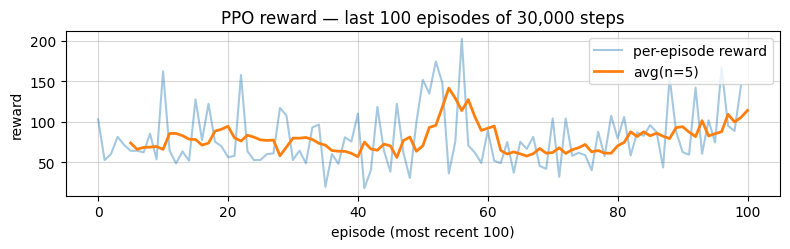

episodes in buffer: 100   recent mean reward: 93.84   recent mean length: 79 steps


In [7]:
# 7. Reward curve from the model's in-memory episode buffer.
ep_rewards = [info["r"] for info in model.ep_info_buffer]
ep_lengths = [info["l"] for info in model.ep_info_buffer]

if ep_rewards:
    plt.figure(figsize=(8, 2.6))
    plt.plot(ep_rewards, alpha=0.4, label="per-episode reward")
    if len(ep_rewards) > 20:
        win = max(5, len(ep_rewards) // 20)
        smoothed = np.convolve(ep_rewards, np.ones(win)/win, mode="valid")
        plt.plot(np.arange(len(smoothed)) + win, smoothed, linewidth=2, label=f"avg(n={win})")
    plt.xlabel("episode (most recent 100)")
    plt.ylabel("reward")
    plt.title(f"PPO reward — last {len(ep_rewards)} episodes of {TOTAL_TIMESTEPS:,} steps")
    plt.legend(); plt.grid(True, alpha=0.5); plt.tight_layout(); plt.show()
    print(f"episodes in buffer: {len(ep_rewards)}   "
          f"recent mean reward: {np.mean(ep_rewards[-min(20, len(ep_rewards)):]):.2f}   "
          f"recent mean length: {np.mean(ep_lengths[-min(20, len(ep_lengths)):]):.0f} steps")
else:
    print("(empty episode buffer — training may have used too few timesteps)")

## 4. Watch the partially-trained policy

The policy at 30 k steps **will not walk** — it usually twitches, scoots, or falls. That's expected for this demo budget. The full notebook (1.5M steps) produces a cleanly-walking policy.

In [8]:
# 8. Trained-policy rollout (100 frames = 2.5 s).
T0 = time.time()
eval_env = HexapodEnv(max_steps=100)
model = PPO.load("/tmp/hexapod_quickdemo", env=eval_env, device=DEVICE)

obs, _ = eval_env.reset(seed=123)
frames, xyz_log = [], []
with mujoco.Renderer(eval_env.model, height=300, width=480) as r:
    for _ in range(100):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, term, trunc, _ = eval_env.step(action)
        xyz_log.append(eval_env.data.qpos[0:3].copy())
        r.update_scene(eval_env.data, "chase")
        frames.append(r.render().copy())
        if term or trunc: break

xyz_log = np.array(xyz_log)
dx = float(xyz_log[-1, 0] - xyz_log[0, 0])
print(f"Rollout: {len(frames)} frames ({len(frames)*0.025:.2f}s sim), chassis dx = {dx:+.3f} m")
print(f"[rollout {time.time()-T0:.1f}s]   [total wallclock: {time.time()-T_START:.1f}s]")
media.show_video(frames, fps=40)

Rollout: 100 frames (2.50s sim), chassis dx = +0.413 m
[rollout 0.6s]   [total wallclock: 18.5s]


This browser does not support the video tag.


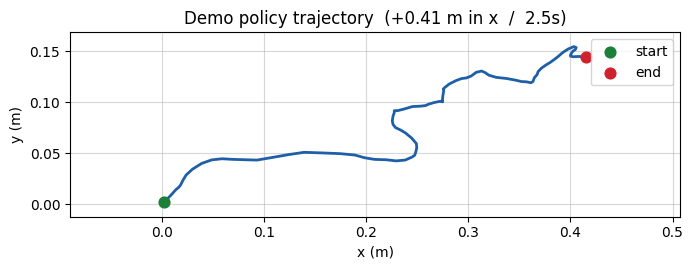

In [9]:
# 9. Top-down trajectory.
plt.figure(figsize=(7, 2.8))
plt.plot(xyz_log[:, 0], xyz_log[:, 1], "-", linewidth=2, color="#1f5fa8")
plt.scatter(*xyz_log[0, :2], s=60, color="#1a7f37", zorder=5, label="start")
plt.scatter(*xyz_log[-1, :2], s=60, color="#cf222e", zorder=5, label="end")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.gca().set_aspect("equal", adjustable="datalim")
plt.title(f"Demo policy trajectory  ({dx:+.2f} m in x  /  {len(frames)*0.025:.1f}s)")
plt.legend(); plt.grid(True, alpha=0.5); plt.tight_layout(); plt.show()

## Next steps after the demo

If the spider didn't walk cleanly: that's expected at 30 k steps. The pipeline ran end-to-end in ≤2 min, which was the goal.

**To actually train a walking policy:** open `robo_greeno_rl_gpu_colab.ipynb` in the same folder. Same model, same env, same algorithm — but `TOTAL_TIMESTEPS = 1_500_000` and a `[256, 256]` policy net, on a `SubprocVecEnv` with 8 envs. Wallclock: ~30 min on T4. Output: a spider that actually walks.

**For real TPU acceleration** (1000+ envs in parallel directly on the accelerator): rewrite the env with **MJX** (JAX-native MuJoCo) and use **Brax**'s PPO. Same hexapod model, but the entire physics simulation moves to the device — typical speedup 20–50× over the SB3 + CPU-env stack used here. That's the proper TPU path for this problem, and it would be a separate notebook.

**Class discussion prompts:**
1. The reward function has six terms with hand-picked coefficients. Which term do you think dominates after 30 k steps? After 1.5M? *(Hint: alive bonus dominates early because it's certain; forward velocity matters more late.)*
2. The action space is delta-from-rest, scaled to ±0.3 rad. Why not raw joint angles? *(Hint: action prior centered on a viable standing pose vs. exploration from random noise that immediately falls over.)*
3. Why was GPU enough here, but the next-step MJX rewrite needs TPU to shine? *(Hint: env-stepping bottleneck on CPU vs. fully-vectorised JAX rollout on device.)*